In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [22]:
df = pd.read_excel('./data/Online_Retail.xlsx', header=0).iloc[0:, 1:]
print(df.shape)
df.head()

(541909, 7)


,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   StockCode    541909 non-null  object        
 1   Description  540455 non-null  object        
 2   Quantity     541909 non-null  int64         
 3   InvoiceDate  541909 non-null  datetime64[us]
 4   UnitPrice    541909 non-null  float64       
 5   CustomerID   406829 non-null  float64       
 6   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(1)
memory usage: 28.9+ MB


In [24]:
df['Datetime'] = pd.to_datetime(df['InvoiceDate'])
df['Datetime']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: Datetime, Length: 541909, dtype: datetime64[us]

In [25]:
df.isnull().sum()

StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Datetime            0
dtype: int64

In [26]:
df['year'] = df.Datetime.apply(lambda x: x.year)
df['month'] = df.Datetime.apply(lambda x: x.month)
df['day'] = df.Datetime.apply(lambda x: x.day)
df['hour'] = df.Datetime.apply(lambda x: x.hour)
df['minute'] = df.Datetime.apply(lambda x: x.minute)
df.head()

,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Datetime,year,month,day,hour,minute
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01 08:26:00,2010,12,1,8,26
1,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,2010,12,1,8,26
2,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01 08:26:00,2010,12,1,8,26
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,2010,12,1,8,26
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,2010,12,1,8,26


In [27]:
df.shape

(541909, 13)

In [28]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df.shape

(397924, 13)

In [30]:
drop_cols = ['InvoiceDate', 'Datetime']
df.drop(drop_cols, axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   StockCode    397924 non-null  object 
 1   Description  397924 non-null  object 
 2   Quantity     397924 non-null  int64  
 3   UnitPrice    397924 non-null  float64
 4   CustomerID   397924 non-null  float64
 5   Country      397924 non-null  str    
 6   year         397924 non-null  int64  
 7   month        397924 non-null  int64  
 8   day          397924 non-null  int64  
 9   hour         397924 non-null  int64  
 10  minute       397924 non-null  int64  
dtypes: float64(2), int64(6), object(2), str(1)
memory usage: 36.4+ MB


In [32]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

customer_df = df.groupby('CustomerID').agg(Frequency=('StockCode', 'count'),
                                           Monetary=('TotalPrice', 'sum')).reset_index()

print(customer_df.shape)
customer_df.head()

(4339, 3)


,CustomerID,Frequency,Monetary
0,12346.0,1,77183.60
1,12347.0,182,4310.00
2,12348.0,31,1797.24
3,12349.0,73,1757.55
4,12350.0,17,334.40


In [44]:
customer_df[['Frequency', 'Monetary']].describe()

,Frequency,Monetary
count,4339.000000,4339.000000
mean,91.708689,2053.793018
std,228.792852,8988.248381
min,1.000000,0.000000
25%,17.000000,307.245000
50%,41.000000,674.450000
75%,100.000000,1661.640000
max,7847.000000,280206.020000


In [33]:
from sklearn.preprocessing import StandardScaler

X = customer_df[['Frequency', 'Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.39651214,  8.35963391],
       [ 0.39468767,  0.25104636],
       [-0.26537405, -0.02854645],
       [-0.08178072, -0.03296273],
       [-0.32657182, -0.19131549]])

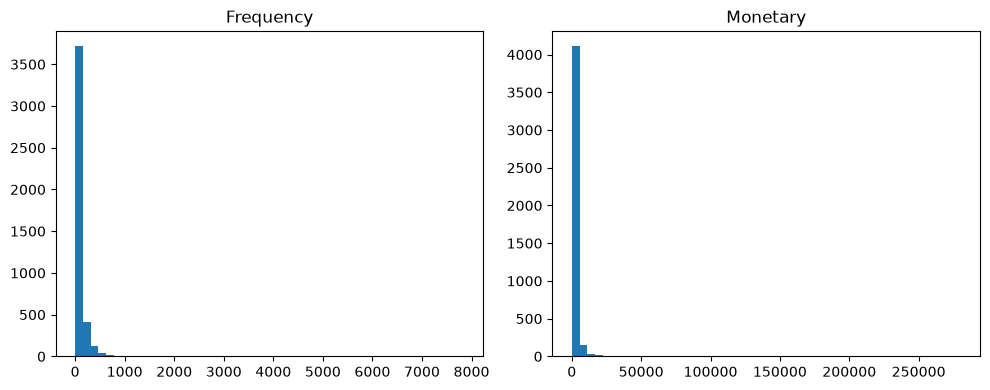

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(customer_df['Frequency'], bins=50)
axes[0].set_title('Frequency')
axes[1].hist(customer_df['Monetary'], bins=50)
axes[1].set_title('Monetary')
plt.tight_layout()
plt.show()

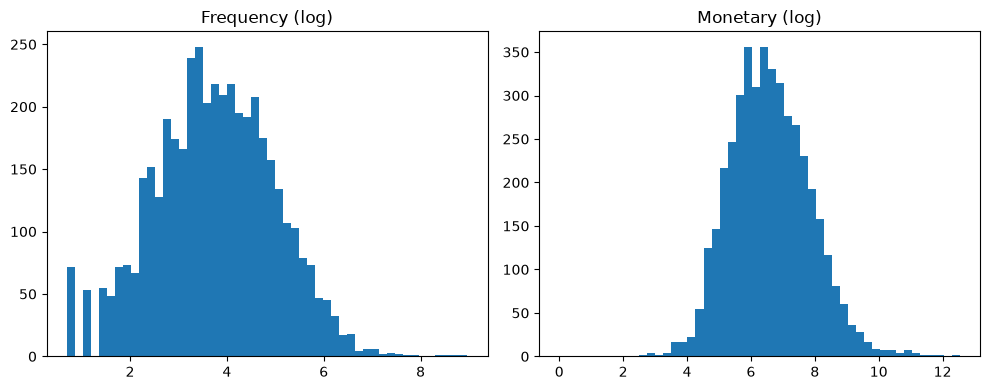

In [46]:
customer_df['Frequency_log'] = np.log1p(customer_df['Frequency'])
customer_df['Monetary_log'] = np.log1p(customer_df['Monetary'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(customer_df['Frequency_log'], bins=50)
axes[0].set_title('Frequency (log)')
axes[1].hist(customer_df['Monetary_log'], bins=50)
axes[1].set_title('Monetary (log)')
plt.tight_layout()
plt.show()

In [47]:
X = customer_df[['Frequency_log', 'Monetary_log']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-2.43282745,  3.69616759],
       [ 1.17736943,  1.40875812],
       [-0.21652101,  0.71551656],
       [ 0.45360881,  0.69782099],
       [-0.67644615, -0.61587654]])

In [65]:
kmeans = KMeans(n_clusters=3,
                init='k-means++',
                max_iter=300,
                random_state=42)

cluster_labels = kmeans.fit_predict(X_scaled)
customer_df['cluster'] = cluster_labels

customer_df['cluster'].value_counts()

cluster
2    1867
0    1370
1    1102
Name: count, dtype: int64

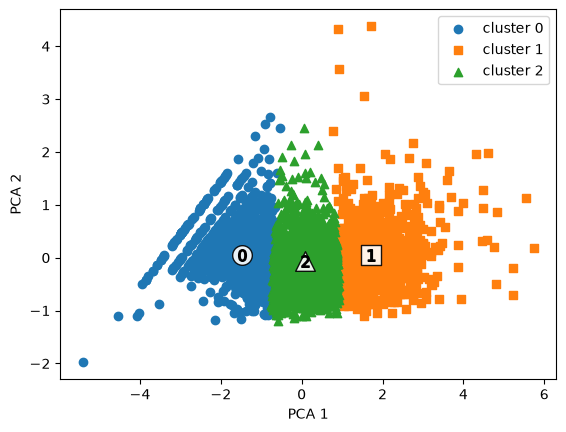

In [69]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

centers = kmeans.cluster_centers_
centers_pca = pca.transform(centers)

customer_df['pca_1'] = pca_result[:, 0]
customer_df['pca_2'] = pca_result[:, 1]

markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

for label in sorted(customer_df['cluster'].unique()):
    cluster_data = customer_df[customer_df['cluster'] == label]
    center = centers_pca[label]

    plt.scatter(x=cluster_data['pca_1'],
                 y=cluster_data['pca_2'],
                marker=markers[label],
                label=f'cluster {label}')
    
    plt.scatter(x=center[0],
                y=center[1],
                s=200,
                color='white',
                alpha=0.9,
                edgecolor='k',
                marker=markers[label])
    plt.scatter(x=center[0],
                y=center[1],
                s=70,
                color='k',
                edgecolor='k',
                marker='$%d$' % label)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

In [67]:
from sklearn.metrics import silhouette_score, silhouette_samples

score = silhouette_score(X_scaled, customer_df['cluster'])
print(score)

0.4099572993687087


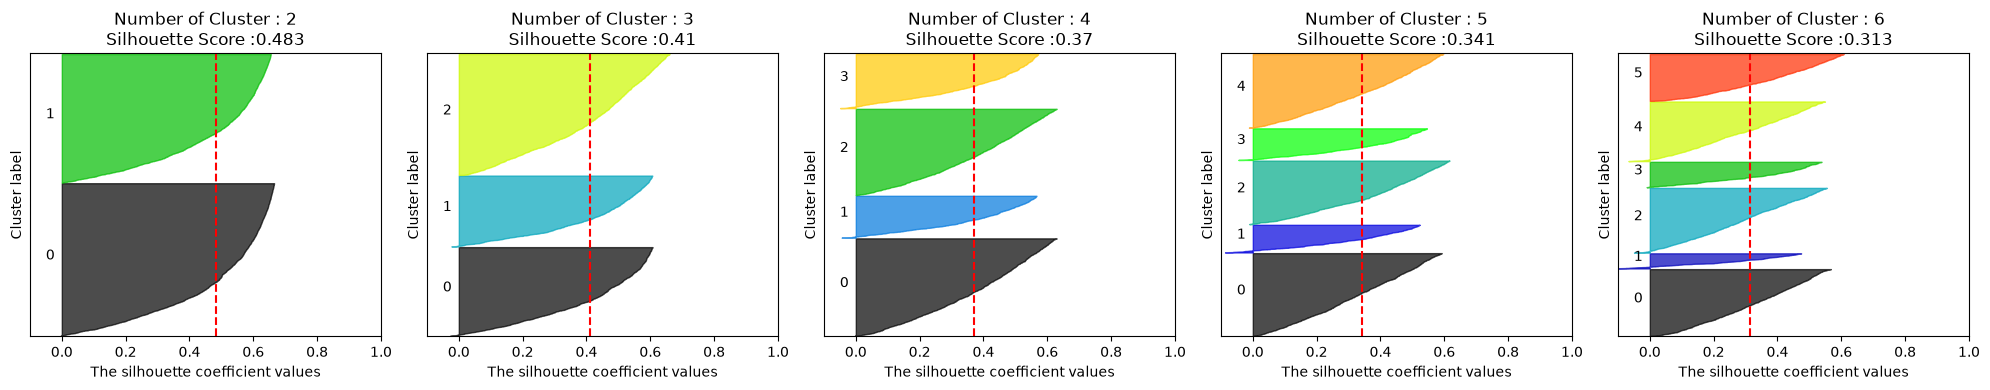

,Frequency,Monetary
cluster,,
0,12.541606,261.711344
1,253.652450,6313.290128
2,54.213712,854.642551


In [68]:
def visualize_silhouette(cluster_lists, X_features): 
    
    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math
    
    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)
    
    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
    
    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):
        
        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)
        
        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)
        
        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

    plt.tight_layout()
    plt.show()

visualize_silhouette([2, 3, 4, 5 ,6], X_scaled)
customer_df.groupby('cluster')[['Frequency', 'Monetary']].mean()